# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('previsao_de_renda.csv')
df['data_ref'] = pd.to_datetime(df['data_ref'])

print(df.shape)
df.head()

(15000, 16)


,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

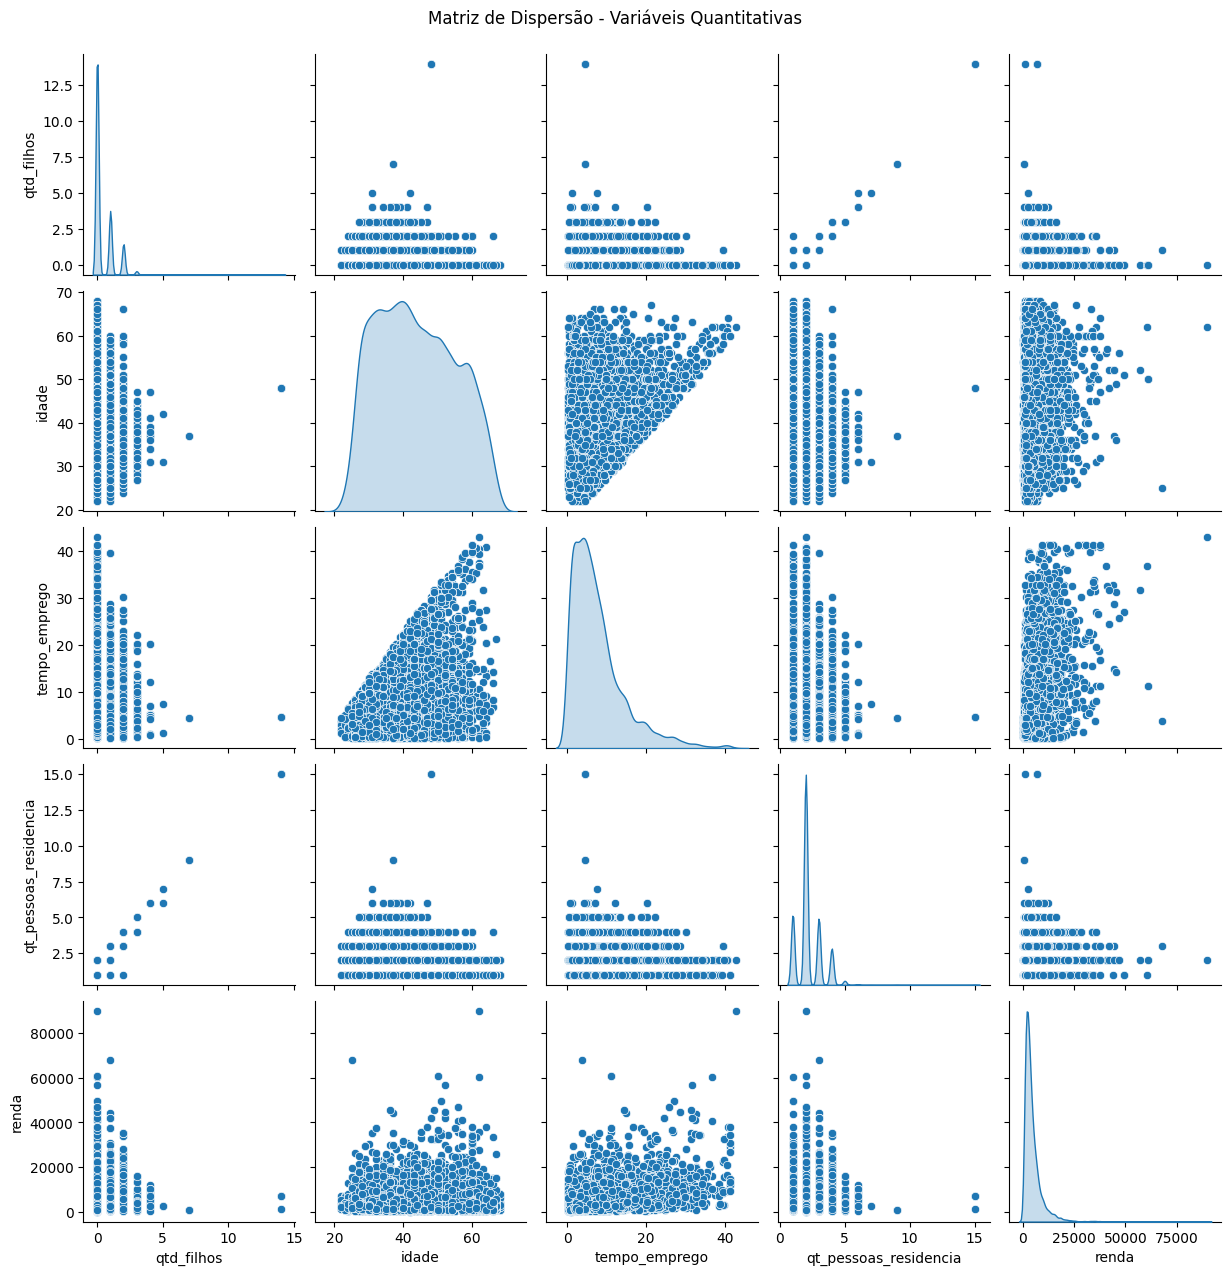

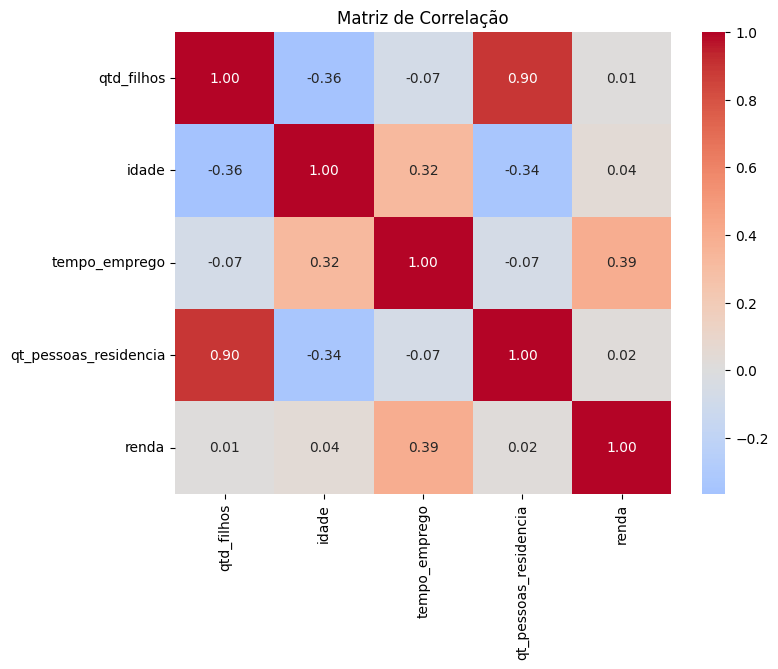

In [5]:
# Seleciona apenas variáveis quantitativas relevantes
quant_vars = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']

# Matriz de dispersão (pairplot)
sns.pairplot(df[quant_vars], diag_kind='kde')
plt.suptitle('Matriz de Dispersão - Variáveis Quantitativas', y=1.02)
plt.show()

# Heatmap de correlação
corr = df[quant_vars].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

2) Avalie um gráfico de dispersão (*scatterplot*) específico para as duas variáveis mais correlacionadas com *renda*.

Correlações com renda:
 tempo_emprego            0.394235
idade                    0.042570
qt_pessoas_residencia    0.020977
qtd_filhos               0.009567
Name: renda, dtype: float64


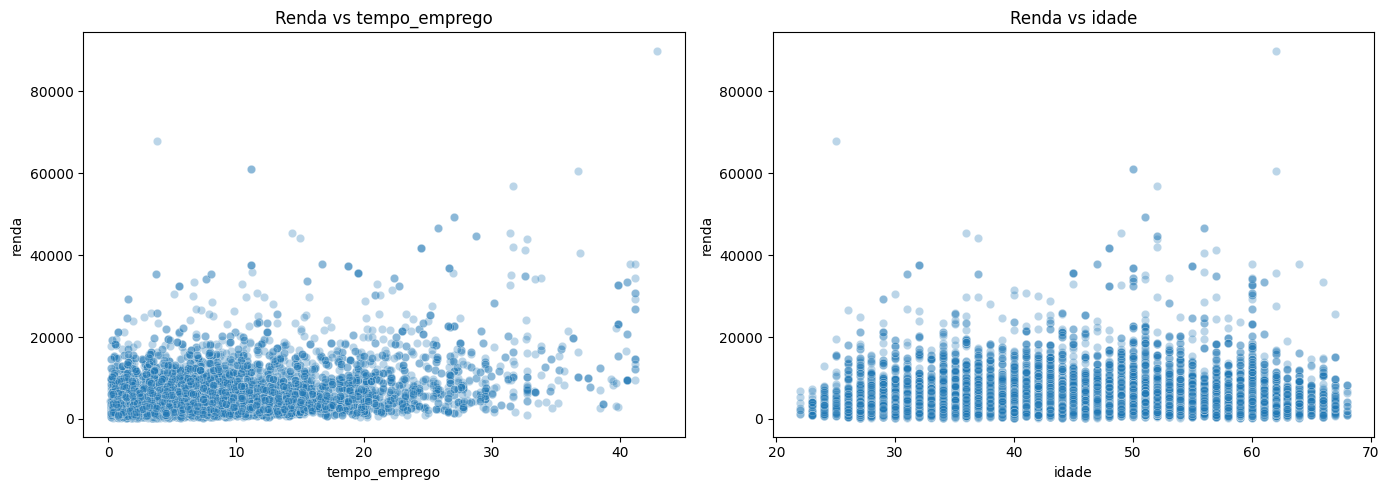

In [6]:
# Identifica as 2 variáveis mais correlacionadas com renda (excluindo a própria renda)
corr_renda = df[quant_vars].corr()['renda'].drop('renda').abs().sort_values(ascending=False)
print("Correlações com renda:\n", corr_renda)

top2 = corr_renda.index[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, var in zip(axes, top2):
    sns.scatterplot(data=df, x=var, y='renda', alpha=0.3, ax=ax)
    ax.set_title(f'Renda vs {var}')
plt.tight_layout()
plt.show()

3) Na su aopinião, há outliers na variável renda?

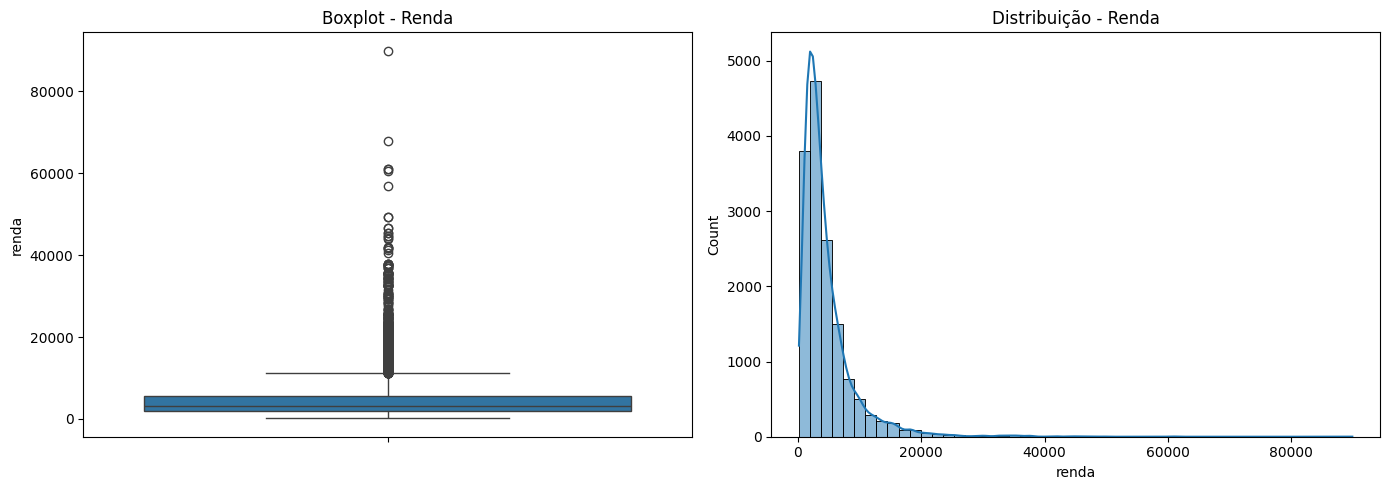

Q1: 1945.74 | Q3: 5642.36 | IQR: 3696.62
Limite superior: 11187.30
Quantidade de outliers: 1026 (6.84%)


In [7]:
# Boxplot de renda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['renda'], ax=axes[0])
axes[0].set_title('Boxplot - Renda')

sns.histplot(df['renda'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribuição - Renda')
plt.tight_layout()
plt.show()

# Cálculo via IQR
Q1 = df['renda'].quantile(0.25)
Q3 = df['renda'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df[df['renda'] > limite_superior]
print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Quantidade de outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

4) Calcule o logaritmo da variável renda e repita a sequência de análise

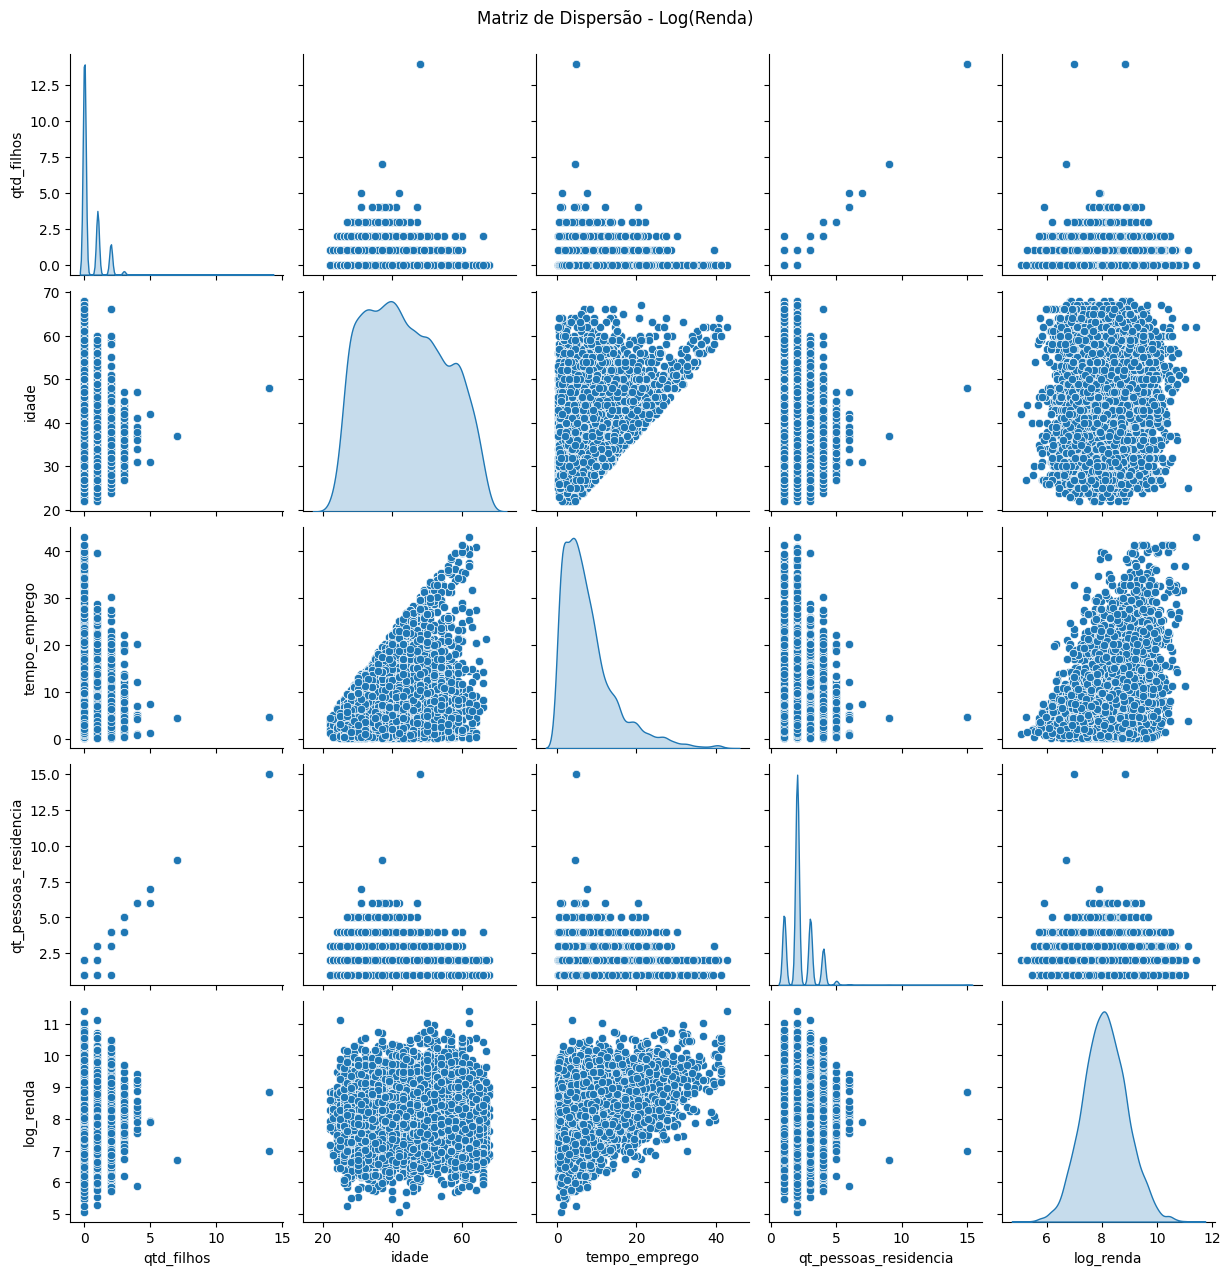

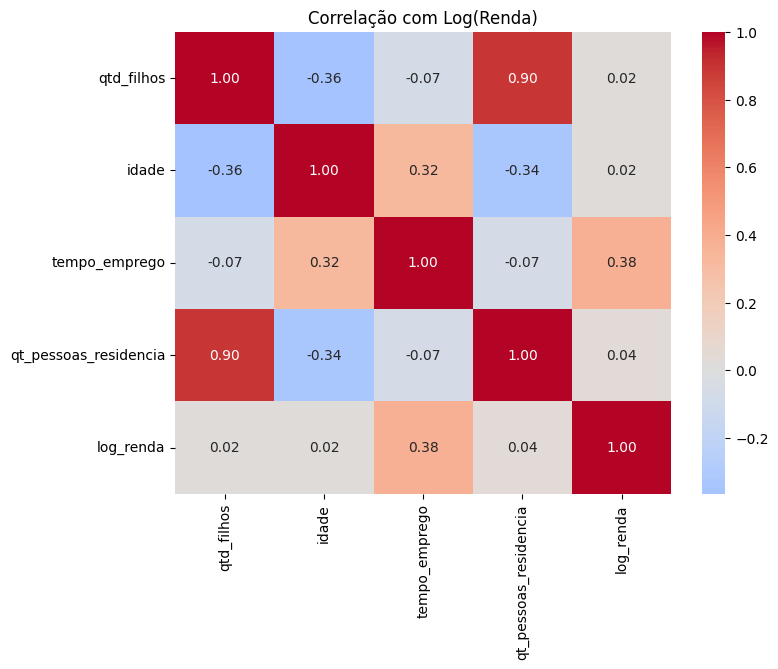

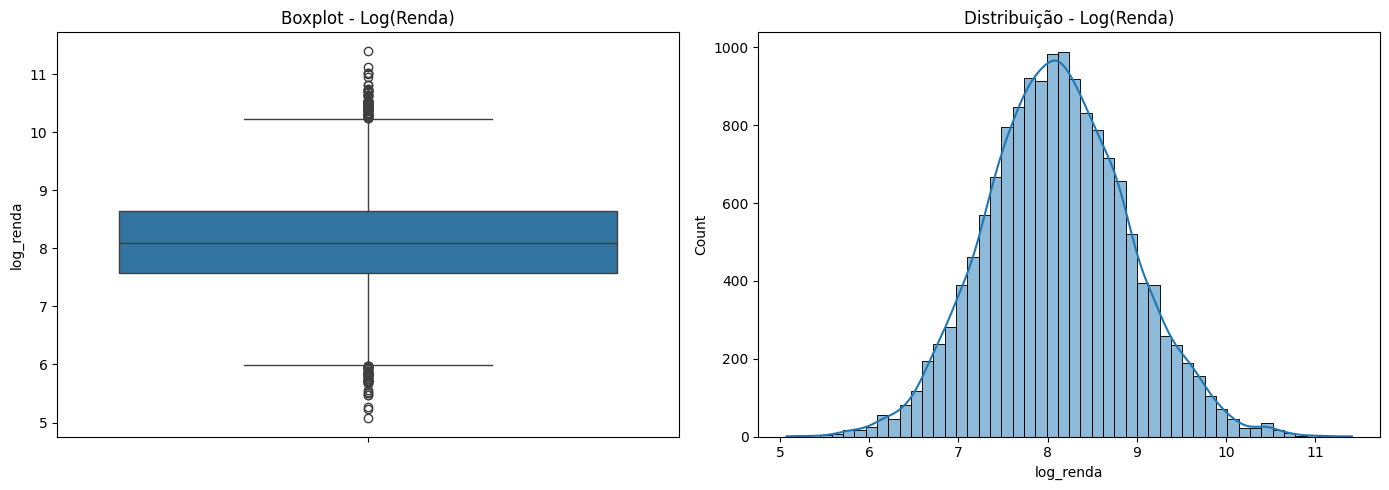

In [8]:
df['log_renda'] = np.log(df['renda'])

quant_log = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'log_renda']

# Pairplot com log_renda
sns.pairplot(df[quant_log], diag_kind='kde')
plt.suptitle('Matriz de Dispersão - Log(Renda)', y=1.02)
plt.show()

# Heatmap com log_renda
corr_log = df[quant_log].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_log, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação com Log(Renda)')
plt.show()

# Boxplot e histograma do log_renda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['log_renda'], ax=axes[0])
axes[0].set_title('Boxplot - Log(Renda)')
sns.histplot(df['log_renda'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribuição - Log(Renda)')
plt.tight_layout()
plt.show()

5) A aplicação do LOG você acha que melhorou ou piorou a análise?

In [9]:
print("=== Correlação com RENDA original ===")
print(df[quant_vars].corr()['renda'].drop('renda').sort_values(ascending=False))

print("\n=== Correlação com LOG(RENDA) ===")
print(df[quant_log].corr()['log_renda'].drop('log_renda').sort_values(ascending=False))

print("""
Análise:
- A transformação LOG tende a reduzir o impacto de outliers e aproximar a distribuição da normalidade.
- Se os coeficientes de correlação aumentaram após o LOG, a transformação melhorou a análise linear.
- Para modelagem preditiva, trabalhar com log(renda) é uma prática comum em modelos de regressão.
""")

=== Correlação com RENDA original ===
tempo_emprego            0.394235
idade                    0.042570
qt_pessoas_residencia    0.020977
qtd_filhos               0.009567
Name: renda, dtype: float64

=== Correlação com LOG(RENDA) ===
tempo_emprego            0.379556
qt_pessoas_residencia    0.036267
idade                    0.024712
qtd_filhos               0.023743
Name: log_renda, dtype: float64

Análise:
- A transformação LOG tende a reduzir o impacto de outliers e aproximar a distribuição da normalidade.
- Se os coeficientes de correlação aumentaram após o LOG, a transformação melhorou a análise linear.
- Para modelagem preditiva, trabalhar com log(renda) é uma prática comum em modelos de regressão.

